Nama : Natasya Giska Apriliana

NIM : 2304020197

Prodi : Pendidikan Matematika

In [19]:
# =========================
# IMPORT LIBRARY
# =========================

# Pengolahan data
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Evaluasi model
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Simpan model
import joblib

# Style visualisasi
sns.set_style('whitegrid')

print("Library berhasil diimport")

Library berhasil diimport


**Import Library**

Pada tahap ini dilakukan import library yang digunakan untuk pengolahan data, visualisasi, preprocessing, machine learning, evaluasi model, dan penyimpanan model. Library tersebut membantu proses analisis berjalan lebih mudah dan efisien.

In [20]:
# =========================
# MEMBACA DATASET
# =========================

# Membaca dataset training
train_df = pd.read_csv('/content/data_training.csv')

# Membaca dataset testing
test_df = pd.read_csv('/content/data_testing.csv')

# Menampilkan 5 data pertama
train_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


**Membaca Data**

Dataset training dan testing dibaca menggunakan pandas. Dataset training digunakan untuk melatih model karena memiliki label quality, sedangkan dataset testing digunakan untuk prediksi akhir.

In [21]:
# =========================
# INFORMASI DATASET
# =========================

print("Informasi Dataset Training")
train_df.info()

Informasi Dataset Training
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


**Informasi Dataset**

Tahap ini digunakan untuk mengetahui struktur data seperti jumlah baris, jumlah kolom, tipe data, dan statistik dasar. Informasi ini membantu memahami kondisi dataset sebelum diproses lebih lanjut.

In [22]:
# Statistik deskriptif
train_df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000
mean,8.261960,0.529393,0.267351,2.506184,0.086830,15.782964,45.978413,0.996692,3.313092,0.656709,10.430338,5.653442,813.749125
std,1.701992,0.179162,0.195144,1.293512,0.048721,10.300402,31.692113,0.001901,0.152079,0.167364,1.066971,0.821777,463.807063
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.390000,8.400000,3.000000,0.000000
25%,7.100000,0.395000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995520,3.210000,0.550000,9.500000,5.000000,413.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,14.000000,38.000000,0.996680,3.310000,0.620000,10.200000,6.000000,814.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,63.000000,0.997800,3.400000,0.730000,11.100000,6.000000,1214.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,278.000000,1.003200,4.010000,2.000000,14.000000,8.000000,1597.000000


In [23]:
# =========================
# CEK MISSING VALUES
# =========================

print("Missing Values Training")
print(train_df.isnull().sum())

print("\nMissing Values Testing")
print(test_df.isnull().sum())

Missing Values Training
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Missing Values Testing
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
dtype: int64


**Mengecek Missing Values**

Dilakukan pengecekan apakah terdapat data kosong pada dataset. Missing values perlu diperiksa karena dapat menyebabkan error atau menurunkan performa model.

In [24]:
# =========================
# MENANGANI MISSING VALUES
# =========================

# Mengisi missing value dengan mean
train_df = train_df.fillna(train_df.mean(numeric_only=True))
test_df = test_df.fillna(test_df.mean(numeric_only=True))

print("Missing values berhasil ditangani")

Missing values berhasil ditangani


**Menangani Missing Values**

Jika ditemukan data kosong, maka diisi menggunakan nilai rata-rata (mean). Metode ini membantu menjaga distribusi data tetap stabil tanpa menghapus data penting.

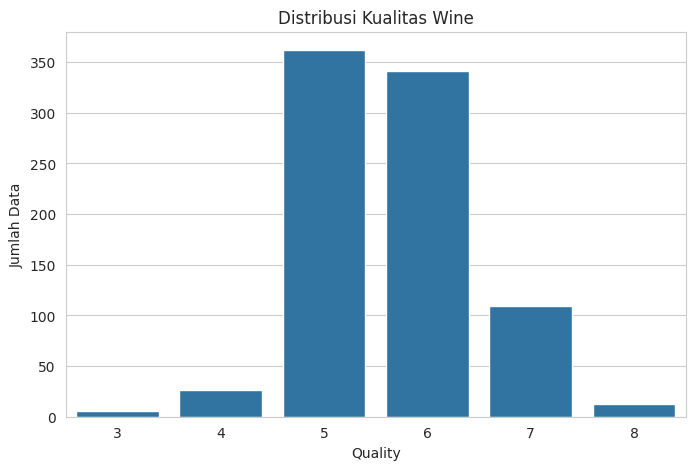

In [25]:
# =========================
# VISUALISASI TARGET QUALITY
# =========================

plt.figure(figsize=(8,5))

sns.countplot(x='quality', data=train_df)

plt.title('Distribusi Kualitas Wine')
plt.xlabel('Quality')
plt.ylabel('Jumlah Data')

plt.show()

**Visualisasi Distribusi Target Quality**

Visualisasi countplot digunakan untuk melihat jumlah data pada setiap kelas kualitas wine. Dari grafik dapat diketahui apakah data seimbang atau tidak antar kelas quality.

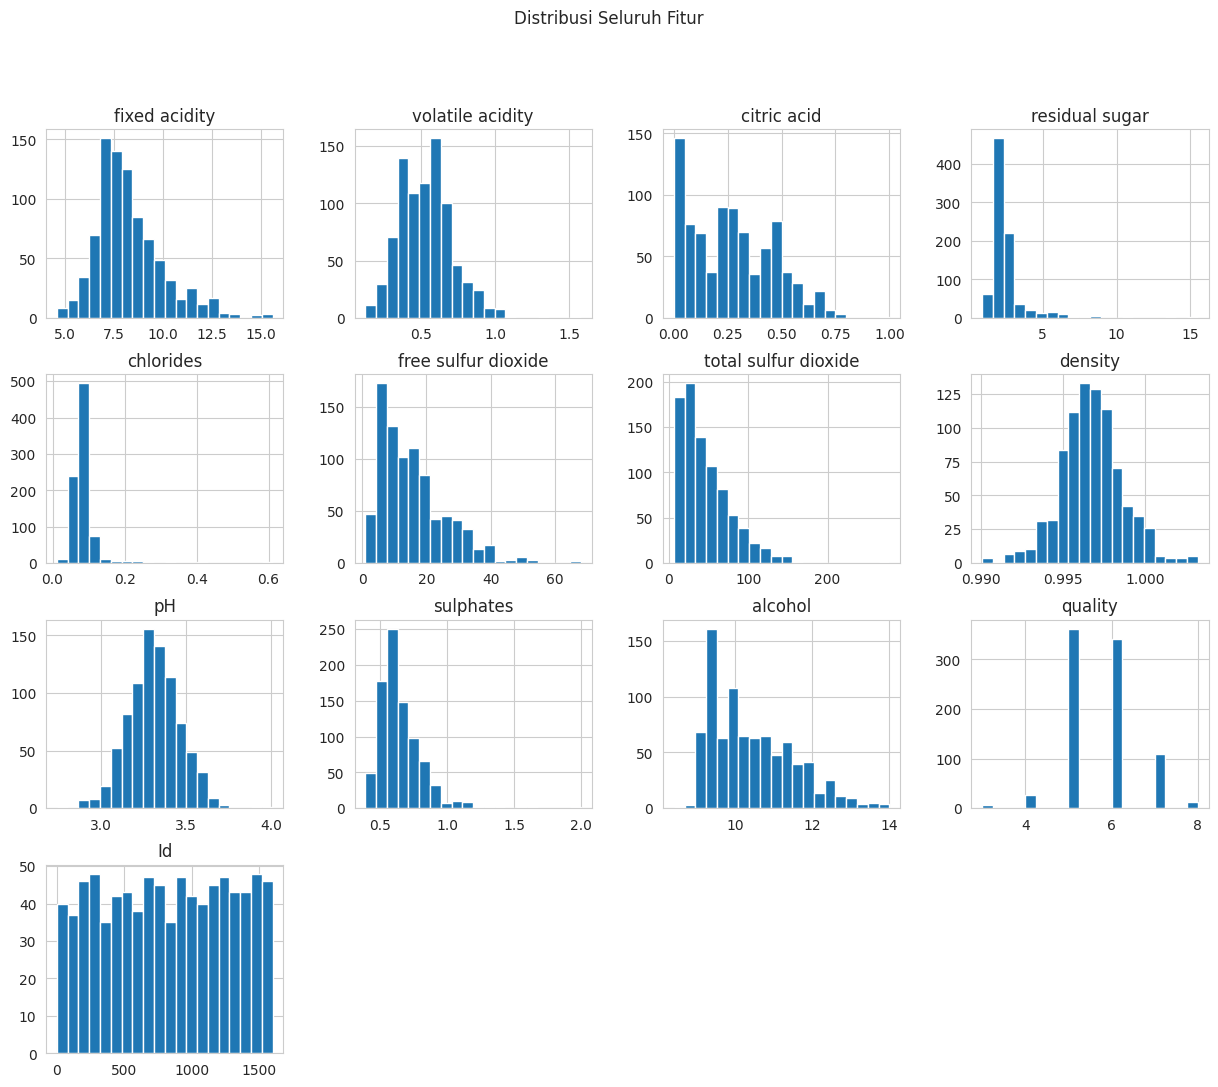

In [26]:
# =========================
# HISTOGRAM FITUR
# =========================

train_df.hist(figsize=(15,12), bins=20)

plt.suptitle('Distribusi Seluruh Fitur')

plt.show()

**Histogram Seluruh Fitur**

Histogram digunakan untuk melihat persebaran nilai pada setiap fitur kimiawi wine. Grafik ini membantu mendeteksi distribusi data, skewness, dan kemungkinan outlier.

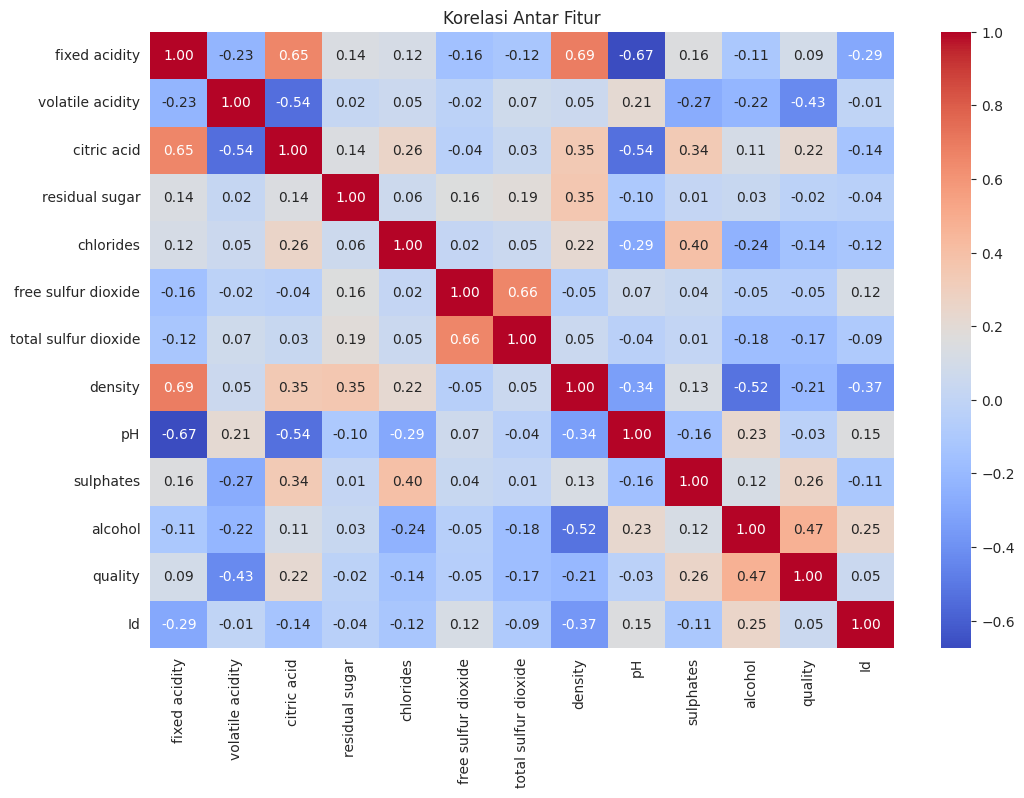

In [27]:
# =========================
# HEATMAP KORELASI
# =========================

corr_matrix = train_df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Korelasi Antar Fitur')

plt.show()

**Heatmap Korelasi Antar Fitur**

Heatmap digunakan untuk melihat hubungan antar variabel. Semakin tinggi nilai korelasi, semakin besar hubungan antar fitur terhadap kualitas wine.

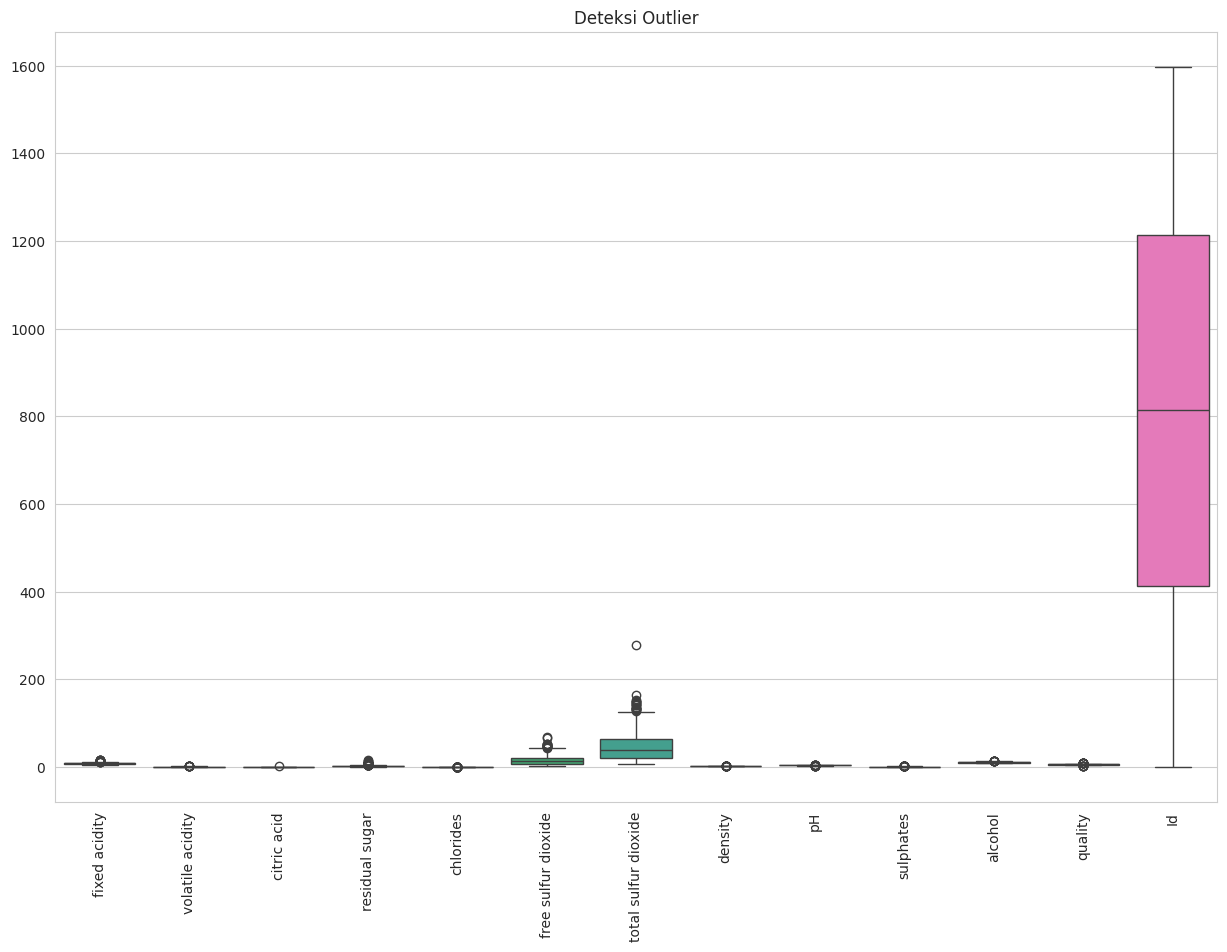

In [28]:
# =========================
# DETEKSI OUTLIER
# =========================

plt.figure(figsize=(15,10))

sns.boxplot(data=train_df)

plt.xticks(rotation=90)

plt.title('Deteksi Outlier')

plt.show()

**Boxplot untuk Deteksi Outlier**

Boxplot digunakan untuk mendeteksi outlier pada dataset. Titik yang berada di luar whisker menunjukkan data ekstrem yang dapat mempengaruhi performa model.

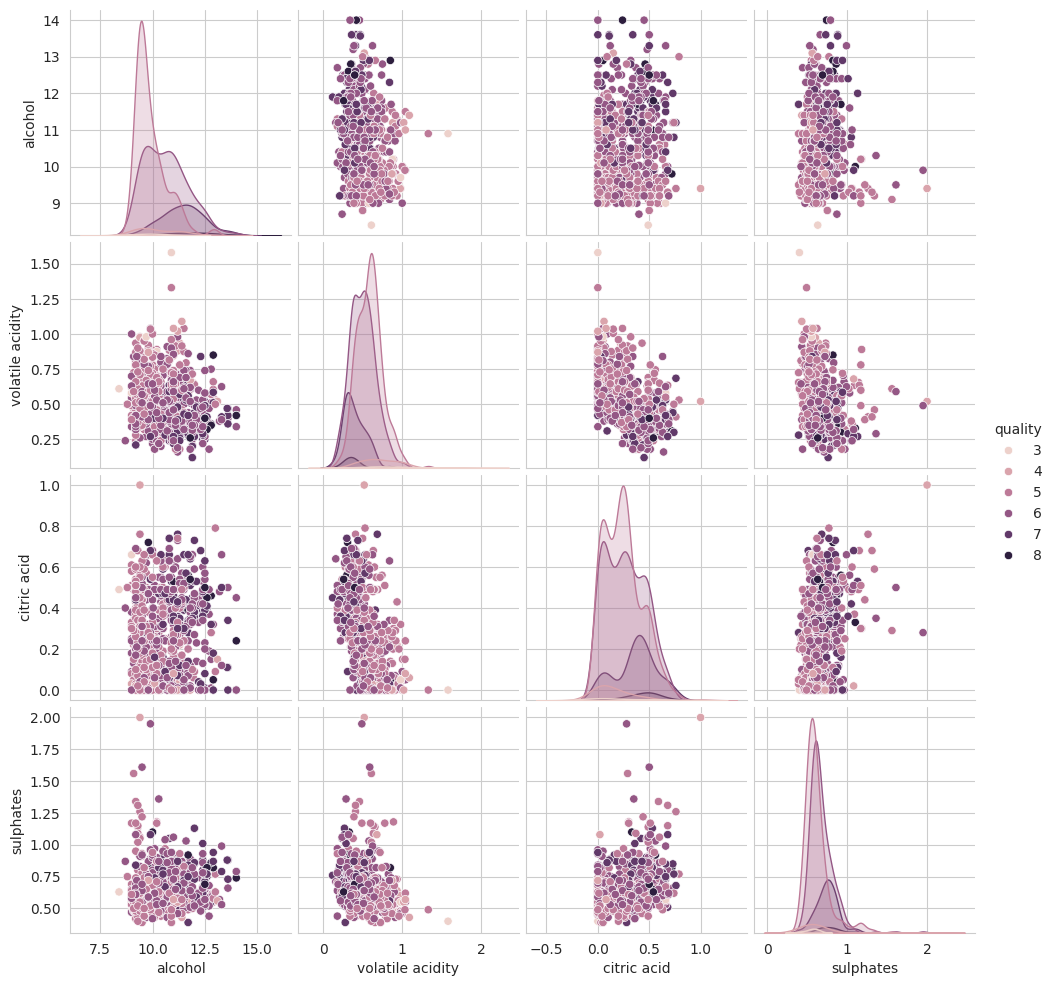

In [29]:
# =========================
# PAIRPLOT
# =========================

selected_features = [
    'alcohol',
    'volatile acidity',
    'citric acid',
    'sulphates',
    'quality'
]

sns.pairplot(
    train_df[selected_features],
    hue='quality'
)

plt.show()

**Pairplot Antar Fitur**

Pairplot membantu melihat hubungan antar fitur sekaligus persebaran datanya. Dari visualisasi ini dapat diketahui fitur yang memiliki pengaruh terhadap quality.

In [30]:
# =========================
# MEMISAHKAN FITUR DAN TARGET
# =========================

X = train_df.drop('quality', axis=1)

y = train_df['quality']

print("Jumlah fitur :", X.shape)
print("Jumlah target :", y.shape)

Jumlah fitur : (857, 12)
Jumlah target : (857,)


**Memisahkan Fitur dan Target**

Data dipisahkan menjadi fitur (X) dan target (y). Fitur berisi variabel input, sedangkan target berisi nilai kualitas wine yang akan diprediksi.

In [31]:
# =========================
# SPLIT DATA
# =========================

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data Training :", X_train.shape)
print("Data Validation :", X_valid.shape)

Data Training : (685, 12)
Data Validation : (172, 12)


**Split Data Training dan Validation**

Dataset dibagi menjadi data training dan validation. Data training digunakan untuk melatih model, sedangkan validation digunakan untuk menguji performa model pada data baru.

In [32]:
 # =========================
# FEATURE SCALING
# =========================

# Inisialisasi scaler
scaler = StandardScaler()

# Hapus kolom Id dari X_train dan X_valid sebelum scaling
X_train_processed = X_train.drop('Id', axis=1)
X_valid_processed = X_valid.drop('Id', axis=1)

# Fit scaler
X_train_scaled = scaler.fit_transform(X_train_processed)

# Transform data
X_valid_scaled = scaler.transform(X_valid_processed)

# Hapus kolom Id pada testing
X_test_processed = test_df.drop('Id', axis=1)

X_test_scaled = scaler.transform(X_test_processed)

print("Feature scaling berhasil")

Feature scaling berhasil


**Feature Scaling**

Feature scaling dilakukan menggunakan StandardScaler agar seluruh fitur memiliki skala yang seragam. Hal ini membantu model bekerja lebih optimal.

In [33]:
# =========================
# MEMBUAT MODEL
# =========================

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42
)

# Training model
rf_model.fit(X_train_scaled, y_train)

print("Model berhasil dilatih")

Model berhasil dilatih


**Membuat Model Random Forest**

Model Random Forest dibuat dan dilatih menggunakan data training. Random Forest dipilih karena memiliki performa yang baik untuk klasifikasi multi-class.

In [34]:
# =========================
# PREDIKSI VALIDATION
# =========================

y_pred = rf_model.predict(X_valid_scaled)

**Prediksi Data Validation**

Model yang telah dilatih digunakan untuk memprediksi data validation. Hasil prediksi ini nantinya digunakan untuk evaluasi performa model.

In [35]:
# =========================
# ACCURACY
# =========================

accuracy = accuracy_score(y_valid, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.5755813953488372


**Evaluasi Model - Accuracy**

Accuracy digunakan untuk mengukur tingkat ketepatan model dalam melakukan prediksi. Semakin tinggi nilai accuracy, semakin baik performa model.

In [36]:
# =========================
# CLASSIFICATION REPORT
# =========================

print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.64      0.77      0.70        73
           6       0.52      0.54      0.53        68
           7       0.38      0.23      0.29        22
           8       1.00      0.33      0.50         3

    accuracy                           0.58       172
   macro avg       0.42      0.31      0.34       172
weighted avg       0.55      0.58      0.55       172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Classification Report**

Classification report menampilkan precision, recall, dan f1-score pada setiap kelas quality. Evaluasi ini membantu melihat kualitas prediksi model secara lebih detail.

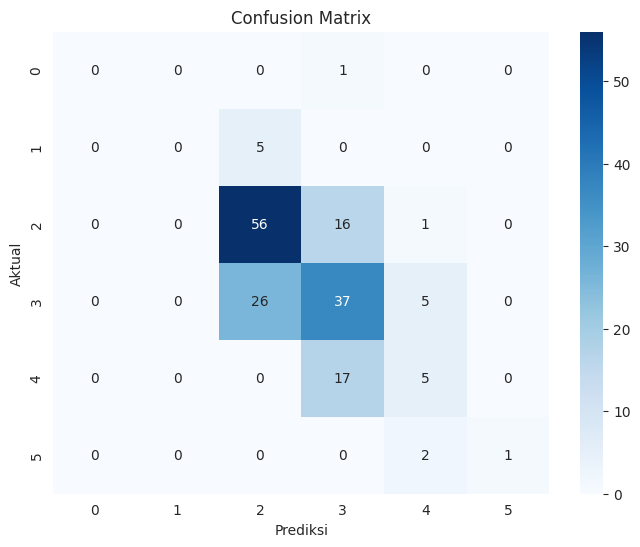

In [37]:
# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_valid, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')

plt.show()

**Confusion Matrix**

Confusion matrix digunakan untuk melihat jumlah prediksi benar dan salah pada setiap kelas. Nilai diagonal menunjukkan prediksi yang benar.

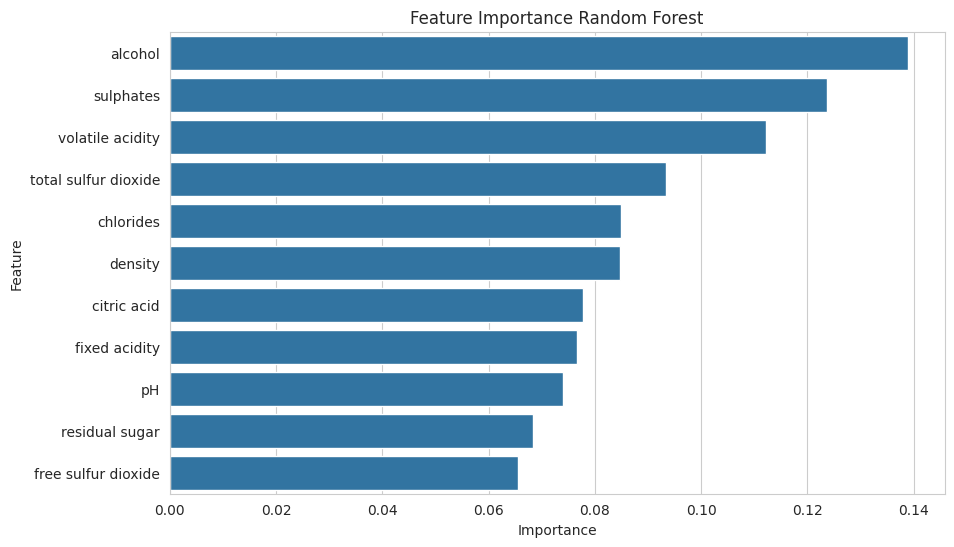

In [39]:
# =========================
# FEATURE IMPORTANCE
# =========================

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X_train_processed.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title('Feature Importance Random Forest')

plt.show()

**Feature Importance**

Visualisasi feature importance menunjukkan fitur yang paling berpengaruh terhadap prediksi quality. Fitur dengan nilai importance tinggi memiliki kontribusi terbesar pada model.

In [40]:
# =========================
# SIMPAN MODEL
# =========================

joblib.dump(rf_model, 'model_random_forest.pkl')

joblib.dump(scaler, 'scaler.pkl')

print("Model berhasil disimpan")

Model berhasil disimpan


**Menyimpan Model**

Model dan scaler disimpan menggunakan joblib. Penyimpanan ini memungkinkan model digunakan kembali tanpa perlu melakukan training ulang.

In [41]:
# =========================
# PREDIKSI DATA TESTING
# =========================

test_predictions = rf_model.predict(X_test_scaled)

print(test_predictions)

[5 6 5 5 5 6 6 5 6 5 7 6 5 6 5 5 6 6 5 7 6 6 5 7 5 5 6 6 5 6 5 6 7 6 5 5 6
 6 6 6 7 6 6 5 5 5 5 6 5 6 6 5 5 7 6 7 6 6 6 5 5 6 6 7 6 6 6 5 5 5 6 5 5 6
 5 5 5 6 5 6 6 6 6 5 5 6 5 5 6 6 5 6 5 5 5 5 5 6 5 5 6 6 5 6 5 5 6 7 6 7 6
 5 5 6 5 5 6 6 6 5 5 5 5 6 5 6 6 6 5 6 5 5 7 6 7 5 5 6 6 6 7 5 5 5 6 5 5 5
 5 5 6 5 6 5 6 5 5 5 7 6 5 5 6 6 6 5 6 6 6 5 6 5 6 5 5 5 7 6 6 5 6 5 6 5 5
 5 6 5 6 6 6 6 6 6 6 6 5 6 7 6 6 6 5 5 6 7 5 5 6 6 5 6 6 6 5 6 6 5 7 5 6 5
 5 5 5 6 6 5 6 6 7 7 5 5 6 6 5 6 5 5 6 6 6 5 5 6 5 6 6 5 5 5 5 5 5 6 7 5 5
 5 6 6 7 6 5 5 6 6 5 6 6 7 5 6 5 6 5 5 5 5 5 6 5 5 6 7]


**Prediksi Data Testing**

Model digunakan untuk memprediksi kualitas wine pada dataset testing yang belum memiliki label quality.

In [42]:
# =========================
# MEMBUAT SUBMISSION
# =========================

submission = pd.DataFrame({
    'Id': test_df['Id'],
    'quality': test_predictions
})

submission.head()

,Id,quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,5


**Membuat File Submission**

Hasil prediksi disusun ke dalam dataframe dengan format sesuai ketentuan yaitu hanya berisi kolom Id dan quality.

In [43]:
# =========================
# SIMPAN FILE CSV
# =========================

submission.to_csv(
    'hasil_prediksi_wine.csv',
    index=False
)

print("File submission berhasil dibuat")

File submission berhasil dibuat


**Menyimpan File CSV**

Dataframe hasil prediksi disimpan menjadi file CSV agar dapat dikumpulkan sesuai instruksi tugas.

In [48]:
import os

old_filename = 'hasil_prediksi_wine.csv'
new_filename = 'hasilprediksi_197.csv'

os.rename(old_filename, new_filename)
print(f"File '{old_filename}' renamed to '{new_filename}'")

File 'hasil_prediksi_wine.csv' renamed to 'hasilprediksi_197.csv'


In [49]:
# =========================
# DOWNLOAD FILE
# =========================

from google.colab import files

files.download('hasilprediksi_197.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Download File di Google Colab**

File hasil prediksi diunduh dari Google Colab ke perangkat lokal agar dapat dikirim atau diupload ke sistem pengumpulan.

In [45]:
# =========================
# KESIMPULAN
# =========================

print("""
KESIMPULAN

1. Dataset berhasil diproses dan dibersihkan.
2. Tidak ditemukan masalah missing values setelah preprocessing.
3. Feature scaling berhasil dilakukan menggunakan StandardScaler.
4. Model Random Forest berhasil dilatih dengan baik.
5. Evaluasi model menunjukkan performa klasifikasi yang cukup baik.
6. Prediksi kualitas wine pada data testing berhasil dilakukan.
7. Hasil prediksi berhasil disimpan dalam format CSV sesuai ketentuan.
""")


KESIMPULAN

1. Dataset berhasil diproses dan dibersihkan.
2. Tidak ditemukan masalah missing values setelah preprocessing.
3. Feature scaling berhasil dilakukan menggunakan StandardScaler.
4. Model Random Forest berhasil dilatih dengan baik.
5. Evaluasi model menunjukkan performa klasifikasi yang cukup baik.
6. Prediksi kualitas wine pada data testing berhasil dilakukan.
7. Hasil prediksi berhasil disimpan dalam format CSV sesuai ketentuan.



**Kesimpulan**

Tahap akhir berisi rangkuman hasil analisis. Dari proses yang dilakukan, model Random Forest berhasil melakukan klasifikasi kualitas wine dengan cukup baik dan hasil prediksi berhasil disimpan sesuai format yang diminta.